<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

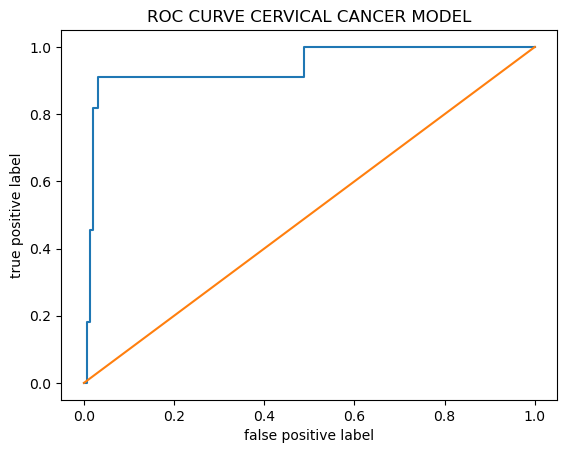

['scaler.pkl']

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import joblib
#input the file data

input = pd.read_csv("cervical-cancer_csv.csv")
input.shape
input.info()
input['Biopsy'].value_counts()
input.columns
#check the missing values
missing = input.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

#drop colums with too many missing values
input = input.drop(columns=[
        "STDs: Time since first diagnosis",
        "STDs: Time since last diagnosis"
])
#handle remaining missing values
input = input.fillna(input.median())
input.isnull().sum()
#separate features and target
x = input.drop("Biopsy", axis=1)
y = input["Biopsy"]
#train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

#feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
#handle oversampling using smote
smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train_scaled, y_train)
#train the model
model = LogisticRegression(max_iter=1000, class_weight = 'balanced')
model.fit(x_train_scaled, y_train)
scores= cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='recall')
print("Recall scores:", scores)
print("average recall:", scores.mean())
#make predictions

y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]

#evaluate the model using confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

#classification report
print(classification_report(y_test, y_pred))

#plot roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("false positive label")
plt.ylabel("true positive label")
plt.title("ROC CURVE CERVICAL CANCER MODEL")
plt.show()
joblib.dump(model, "cervical_cancer.pkl")
joblib.dump(scaler, "scaler.pkl")




IndentationError: unindent does not match any outer indentation level (<tokenize>, line 12)